In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("ggplot")

In [15]:
df = pd.read_csv("data/raw/retail_sales.csv")

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [16]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      str    
 1   store_id  str    
 2   item_id   str    
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 385.9 MB


date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["date"] = pd.to_datetime(df["date"])

In [19]:
df = df.set_index("date")

df.head()

,store_id,item_id,sales,price,promo,weekday,month
date,,,,,,,
2019-01-01,store_1,item_1,41,21.30,0,1,1
2019-01-02,store_1,item_1,53,21.30,0,2,1
2019-01-03,store_1,item_1,39,21.30,0,3,1
2019-01-04,store_1,item_1,35,21.30,0,4,1
2019-01-05,store_1,item_1,51,17.04,1,5,1


In [20]:
full_dates = pd.date_range(df.index.min(), df.index.max())

missing_dates = full_dates.difference(df.index.unique())

print("Missing Dates:", len(missing_dates))

Missing Dates: 0


In [34]:
product_df = df[
    (df["store_id"] == "store_1") &
    (df["item_id"] == "item_1")
]

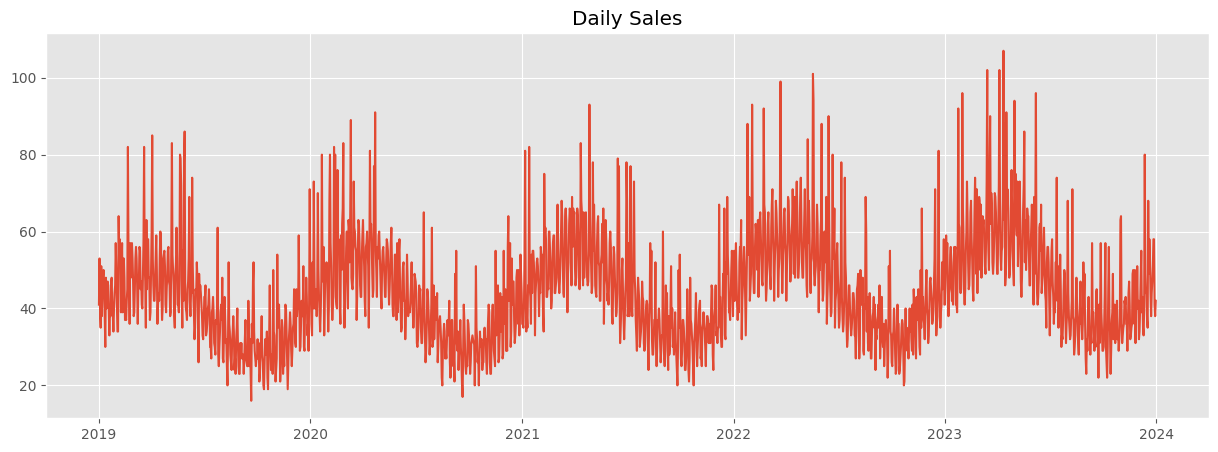

In [35]:
plt.figure(figsize=(15,5))

plt.plot(product_df.index, product_df["sales"])

plt.title("Daily Sales")

plt.show()

In [36]:
monthly_sales = product_df["sales"].resample("ME").sum()

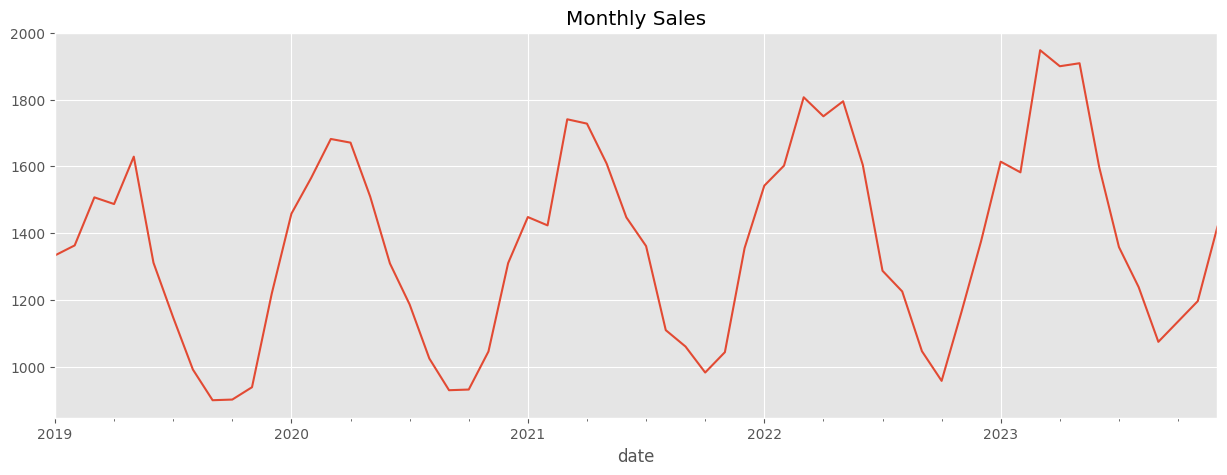

In [37]:
monthly_sales.plot(figsize=(15,5))
plt.title("Monthly Sales")
plt.show()

In [38]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (4565000, 7)

Columns:
['store_id', 'item_id', 'sales', 'price', 'promo', 'weekday', 'month']


In [39]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [40]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 1834500


In [41]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (2730500, 7)


In [42]:
df.dtypes

store_id        str
item_id         str
sales         int64
price       float64
promo         int64
weekday       int64
month         int64
dtype: object

In [43]:
df = df.sort_index()

df.head()

,store_id,item_id,sales,price,promo,weekday,month
date,,,,,,,
2019-01-01,store_1,item_1,41,21.30,0,1,1
2019-01-01,store_49,item_23,9,76.30,0,1,1
2019-01-01,store_27,item_17,19,43.45,0,1,1
2019-01-01,store_4,item_23,13,27.44,0,1,1
2019-01-01,store_20,item_8,21,59.09,0,1,1


In [44]:
date_range = pd.date_range(
    start=product_df.index.min(),
    end=product_df.index.max(),
    freq="D"
)

print("Expected Days:", len(date_range))
print("Actual Days:", len(product_df))

Expected Days: 1826
Actual Days: 1826


In [45]:
product_df = product_df.reindex(date_range)

product_df.head()

,store_id,item_id,sales,price,promo,weekday,month
2019-01-01,store_1,item_1,41,21.30,0,1,1
2019-01-02,store_1,item_1,53,21.30,0,2,1
2019-01-03,store_1,item_1,39,21.30,0,3,1
2019-01-04,store_1,item_1,35,21.30,0,4,1
2019-01-05,store_1,item_1,51,17.04,1,5,1


In [46]:
product_df["sales"] = product_df["sales"].fillna(0)

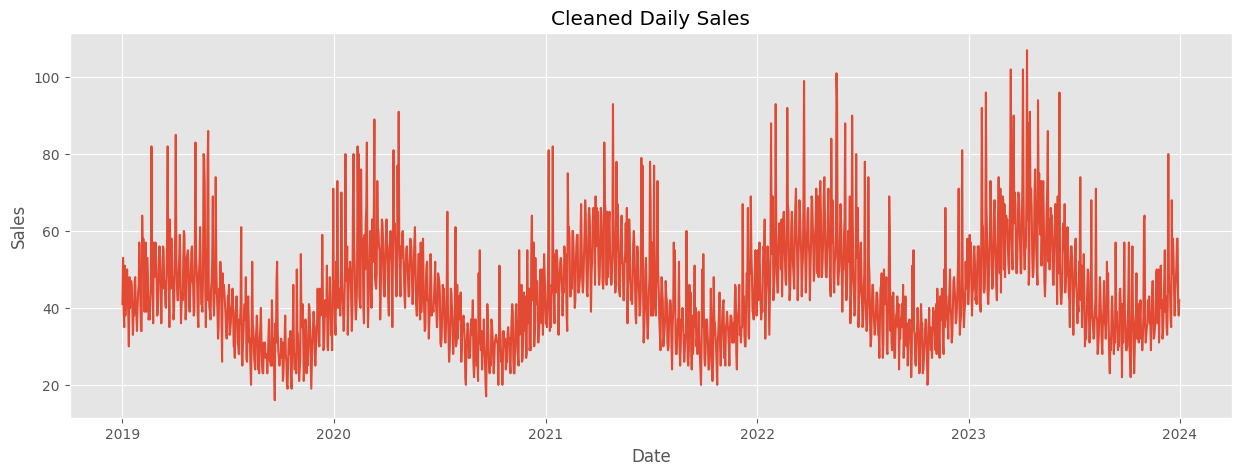

In [47]:
plt.figure(figsize=(15,5))

plt.plot(product_df.index, product_df["sales"])

plt.title("Cleaned Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [48]:
weekly_sales = product_df["sales"].resample("W").sum()

weekly_sales.head()

2019-01-06    257
2019-01-13    303
2019-01-20    291
2019-01-27    285
2019-02-03    306
Freq: W-SUN, Name: sales, dtype: int64

In [50]:
monthly_sales = product_df["sales"].resample("ME").sum()

monthly_sales.head()

2019-01-31    1333
2019-02-28    1363
2019-03-31    1507
2019-04-30    1487
2019-05-31    1629
Freq: ME, Name: sales, dtype: int64

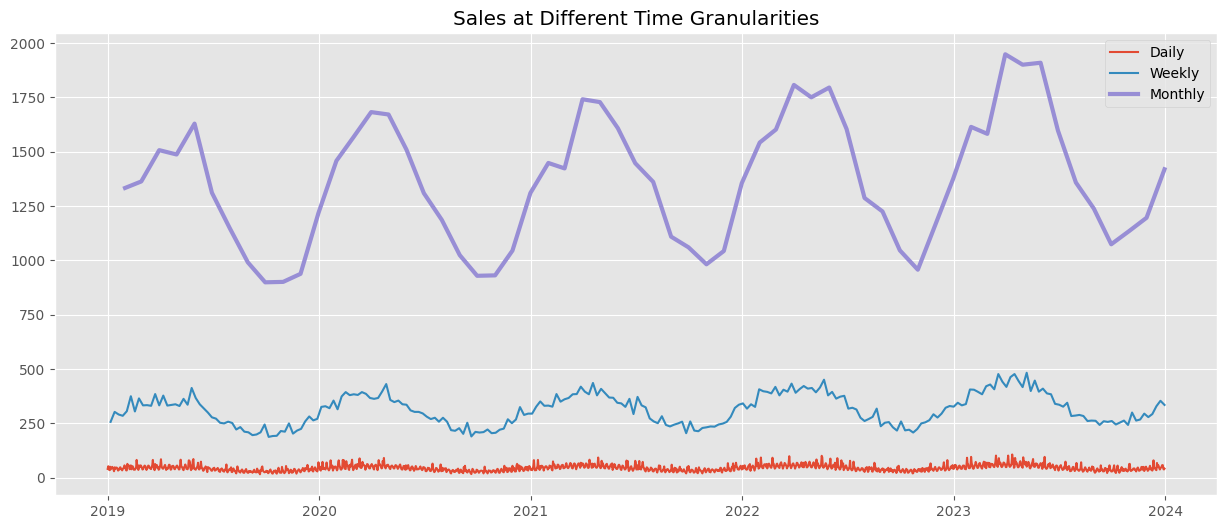

In [51]:
plt.figure(figsize=(15,6))

plt.plot(product_df.index, product_df["sales"], label="Daily")

plt.plot(weekly_sales.index, weekly_sales, label="Weekly")

plt.plot(monthly_sales.index, monthly_sales, linewidth=3, label="Monthly")

plt.legend()

plt.title("Sales at Different Time Granularities")

plt.show()

In [52]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

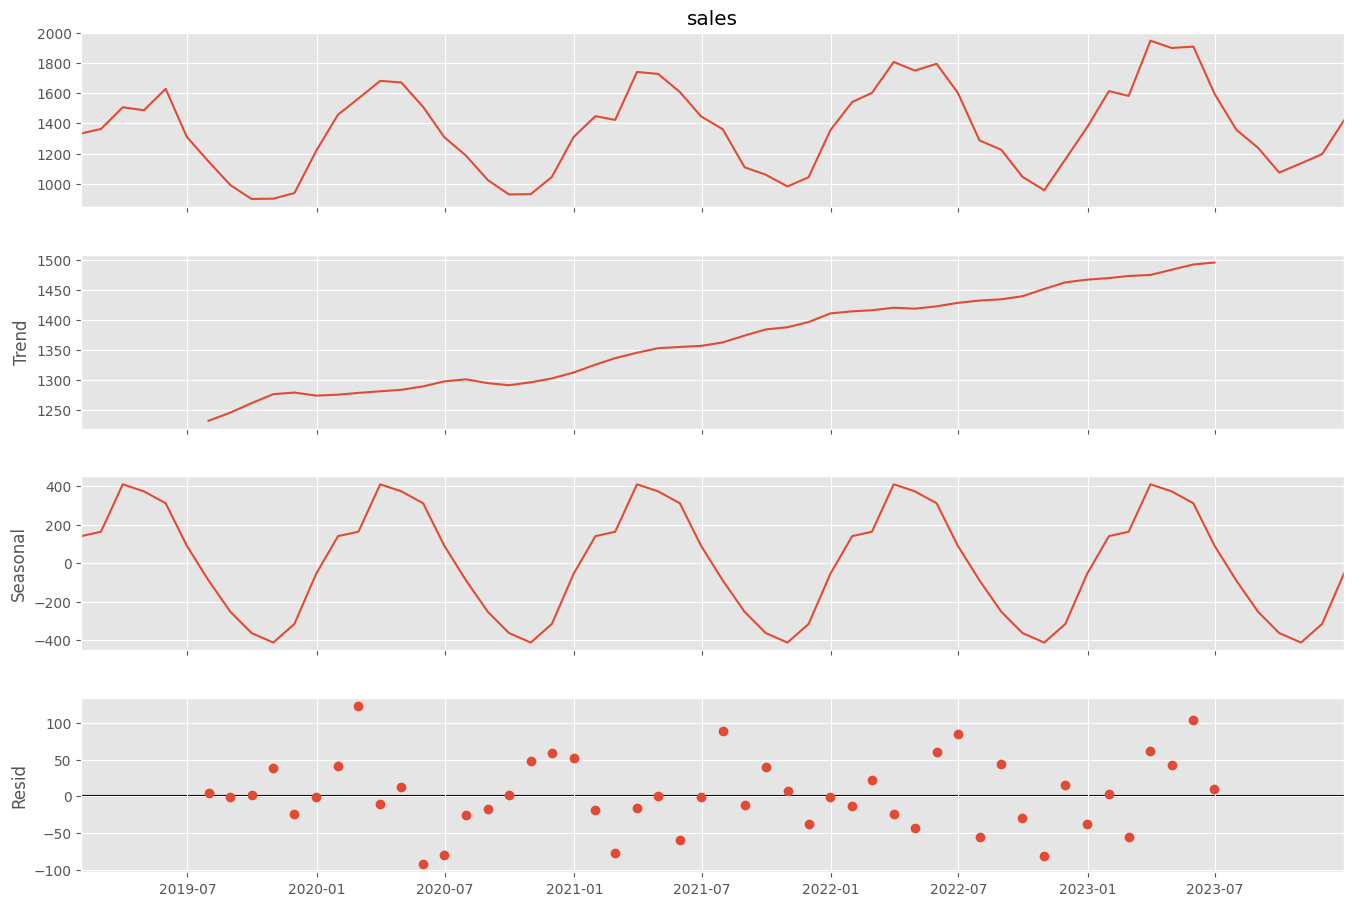

In [53]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

In [56]:
import os

output_path = "data/processed"

os.makedirs(output_path, exist_ok=True)

product_df.to_csv(
    os.path.join(output_path, "clean_sales.csv")
)